# Propensity Modeling and Pre-Treatment Balance Diagnostics

## Scenario
A product team ran a promotional upgrade offer to a subset of users.
Because offer assignment was not randomized, treated and control groups may differ
on key observable characteristics. Before estimating any effect, you need to build
a propensity model and evaluate whether a fair comparison is possible.

## Your task
You will produce:
1. A fitted propensity score model using required covariates
2. A treated vs. control propensity overlap plot
3. A standardized mean difference (SMD) table for numeric covariates (before weighting)
4. A written assessment of overlap adequacy and covariate imbalance

## Requirements
- Use `observational_offer_adoption.csv`
- Treatment: `offer_received`
- Covariates: `age`, `tenure_days`, `prior_spend_12m`, `sessions_30d` (numeric)
  plus `region`, `device` (categorical — must be encoded)
- Report SMD for all four numeric covariates
- SMD threshold: |SMD| > 0.1 indicates meaningful imbalance

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from pathlib import Path
PROJECT_DIR = Path(r"/content/drive/Othercomputers/My PC/Desktop/All_Work_Related/Udacity/Applied_Statistics_ND/Project")
DATA_DIR = PROJECT_DIR / "Project_Data"
if not DATA_DIR.exists():
    DATA_DIR = Path("Project_Data")

CHOICE_PATH  = DATA_DIR / "choice_conjoint_tasks.csv"
BUNDLES_PATH = DATA_DIR / "candidate_bundles.csv"
ADOPT_PATH   = DATA_DIR / "observational_offer_adoption.csv"
SURVEY_PATH  = DATA_DIR / "survey_value_drivers.csv"
MMM_PATH     = DATA_DIR / "marketing_weekly_channels.csv"
print("DATA_DIR:", DATA_DIR.resolve())

DATA_DIR: /content/drive/Othercomputers/My PC/Desktop/All_Work_Related/Udacity/Applied_Statistics_ND/Project/Project_Data


In [3]:
# ── Step 1: Load the data and define treatment ────────────────────────────
df = pd.read_csv(ADOPT_PATH)
print(df.shape)
print("Treatment balance:")
print(df['offer_received'].value_counts())
df.head()

(50000, 10)
Treatment balance:
offer_received
0    27830
1    22170
Name: count, dtype: int64


,user_id,age,tenure_days,region,device,prior_spend_12m,sessions_30d,offer_received,upgraded_to_new_tier,new_tier_monthly_revenue
0,1,54,675,NaN,iOS,8.99,6,1,0,0.00
1,2,59,540,NaN,Android,1.64,5,0,0,0.00
2,3,50,821,APAC,Web,5.96,8,1,1,5.38
3,4,24,548,NaN,Web,1.36,11,0,0,0.00
4,5,18,47,NaN,Web,5.41,11,1,0,0.00


In [4]:
# ── Step 2: Encode categorical covariates ─────────────────────────────────
# Encode region and device as dummies; drop_first removes one reference level
df_enc = pd.get_dummies(df, columns=['region','device'], drop_first=True)
encoded_cat_cols = [c for c in df_enc.columns if c.startswith(('region_','device_'))]

numeric_covs = ['age','tenure_days','prior_spend_12m','sessions_30d']
all_covs = numeric_covs + encoded_cat_cols
print(f"Total covariates: {len(all_covs)}")
print(f"  Numeric: {numeric_covs}")
print(f"  Encoded categoricals: {encoded_cat_cols}")

Total covariates: 8
  Numeric: ['age', 'tenure_days', 'prior_spend_12m', 'sessions_30d']
  Encoded categoricals: ['region_EU', 'region_LATAM', 'device_Web', 'device_iOS']


In [5]:
# ── Step 3: Fit the propensity model ──────────────────────────────────────
# Logistic regression predicts P(offer_received=1 | covariates)
X = df_enc[all_covs].astype(float)
y = df_enc['offer_received']

prop_model = LogisticRegression(max_iter=500, random_state=42)
prop_model.fit(X, y)

# Predicted propensity score for each user
df_enc['propensity'] = prop_model.predict_proba(X)[:, 1]
print(df_enc['propensity'].describe().round(4))

count    50000.0000
mean         0.4434
std          0.0749
min          0.2628
25%          0.3815
50%          0.4423
75%          0.5033
max          0.8821
Name: propensity, dtype: float64


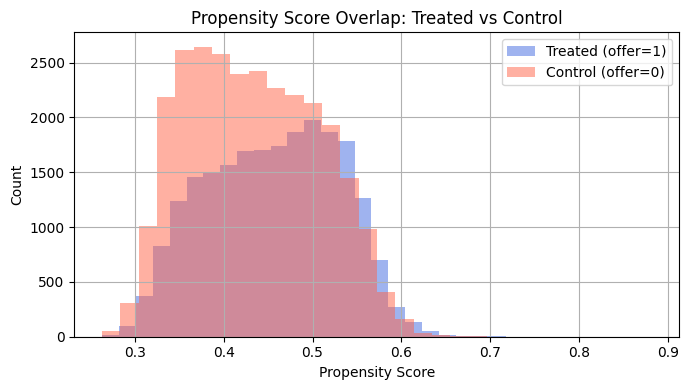

In [6]:
# ── Step 4: Propensity overlap plot ───────────────────────────────────────
# Overlap between treated and control distributions shows whether comparison is viable
treated = df_enc[df_enc['offer_received'] == 1]
control = df_enc[df_enc['offer_received'] == 0]

plt.figure(figsize=(7, 4))
treated['propensity'].hist(alpha=0.5, bins=30, label='Treated (offer=1)', color='royalblue')
control['propensity'].hist(alpha=0.5, bins=30, label='Control (offer=0)',  color='tomato')
plt.xlabel("Propensity Score")
plt.ylabel("Count")
plt.title("Propensity Score Overlap: Treated vs Control")
plt.legend()
plt.tight_layout()
plt.show()

SMD before IPW (|value| > 0.1 = meaningful imbalance):
age                0.0067
tenure_days        0.2824
prior_spend_12m    0.0687
sessions_30d       0.0697
Name: SMD (before IPW), dtype: float64


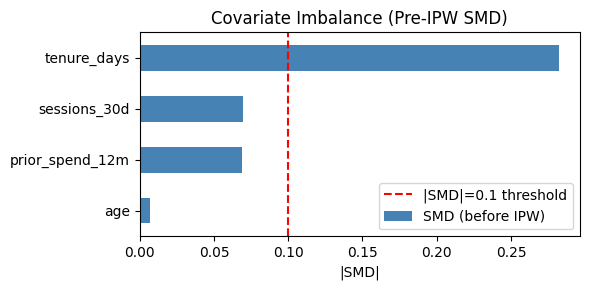

In [7]:
# ── Step 5: Standardized Mean Differences (pre-weighting) ─────────────────
def smd(col, t, c):
    # Standardized mean difference for covariate balance assessment
    pooled_std = np.sqrt((t[col].var() + c[col].var()) / 2 + 1e-9)
    return (t[col].mean() - c[col].mean()) / pooled_std

smd_before = pd.Series(
    {v: smd(v, treated, control) for v in numeric_covs}
).rename("SMD (before IPW)")

print("SMD before IPW (|value| > 0.1 = meaningful imbalance):")
print(smd_before.round(4))

# Plot for clarity
plt.figure(figsize=(6, 3))
smd_before.abs().sort_values().plot(kind='barh', color='steelblue')
plt.axvline(0.1, color='red', linestyle='--', label='|SMD|=0.1 threshold')
plt.xlabel("|SMD|")
plt.title("Covariate Imbalance (Pre-IPW SMD)")
plt.legend()
plt.tight_layout()
plt.show()

## Overlap and Balance Assessment

In the markdown cell below, answer:
1. Does the overlap plot show adequate common support? What would "poor overlap" look like?
2. Which covariate shows the largest SMD? What does that imply about the selection process?
3. Based on the diagnostics, is a propensity-adjusted analysis feasible here?
   Give a one-sentence justification.

In [8]:
# Summary: flag imbalanced covariates
imbalanced = smd_before[smd_before.abs() > 0.1]
print("Covariates with |SMD| > 0.1 (require adjustment):")
print(imbalanced.round(4))
print()
print("Overlap note: if both treated and control propensity distributions cover a similar")
print("range with substantial overlap, IPW-based adjustment is feasible.")

Covariates with |SMD| > 0.1 (require adjustment):
tenure_days    0.2824
Name: SMD (before IPW), dtype: float64

Overlap note: if both treated and control propensity distributions cover a similar
range with substantial overlap, IPW-based adjustment is feasible.
